## Important to know about this Notebook

**1. Required packages**:
```bash
pip install -r requirements.txt
```

**2. Github Error in Code blocks**:

Sometimes, when you open the notebook in GitHub, the code blocks are not formatted correctly. This issue with Jupyter Notebooks on GitHub has happened multiple times. The code blocks are formatted correctly when you open the notebook in Visual Studio Code, and maybe other IDEs. If you encounter this issue, please try opening the notebook in a different IDE.

**3. Table of Contents**:

Our Table of Contents is manually created. We tried both using a [Jupyter TOC](https://marketplace.visualstudio.com/items?itemName=xelad0m.jupyter-toc) extension and by linking directly to markdown headers using anchor links. However, both methods did not work as expected, and therefore we decided to create a manual table of contents.

## Imports needed for this Notebook 

In [265]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import pickle

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

## Table of contents

[**TODO**]

1. Data selection and preparation

    1.1 X

    1.2 Y

2. Data exploration and visualization

    2.1 X

    2.2 Y

3. Model selection and training

    3.1 X

    3.2 Y

## 1. Data selection and preparation:

This section will include:
- Loading the data
- Cleaning the data

This exam project is based on the dataset [Car Prices Dataset](https://www.kaggle.com/datasets/sidharth178/car-prices-dataset?select=train.csv) from [kaggle.com](https://kaggle.com)

### 1.1 Load data

In [266]:
base_path = "..\\"
base_path_data = f'{base_path}\\data\\'
base_path_models = f'{base_path}\\part1\\models\\'

In [267]:
df = pd.read_csv(f'{base_path_data}dataset.csv', sep=',', header=0)

In [268]:
df.sample(5)

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
9891,45806661,706,919,FORD,Fusion,2012,Sedan,Yes,Petrol,3,149822 km,6.00,Automatic,Front,04-May,Left wheel,Blue,12
6692,45812787,1646,777,TOYOTA,Camry,2014,Sedan,Yes,Petrol,2.5,92891 km,4.00,Automatic,Front,04-May,Left wheel,White,12
311,45752253,12701,900,HONDA,Cr-v,2015,Jeep,Yes,Petrol,2.4,117158 km,4.00,Automatic,Front,04-May,Left wheel,White,12
14807,45787438,12231,-,NISSAN,X-Trail,2004,Universal,Yes,Petrol,2,170000 km,3.00,Automatic,4x4,04-May,Left wheel,Golden,2
9219,45798462,18817,-,HYUNDAI,Veloster,2013,Hatchback,No,Petrol,1.6,80000 km,4.00,Tiptronic,Front,04-May,Left wheel,White,4


**Data Explanation**:

- `#`: Unique ID for each column
- `ID`: Unique ID for each car
- `Price`: Price of the car
- `Levy`: Tax on the car
- `Manufacturer`: Manufacturer of the car
- `Model`: Model of the car
- `Prod. year`: Production year of the car
- `Category`: Which category the car belongs to
- `Leather interior`: If the car has leather interior
- `Fuel type`: Fuel type of the car
- `Engine volume`: Engine volume of the car
- `Mileage`: How many kilometers the car has driven
- `Cylinders`: Number of cylinders in the car
- `Gear box type`: Type of gear box
- `Drive wheels`: Which wheels are driven
- `Doors`: Amount of doors
- `Wheel`: If steering wheel is left or right
- `Color`: Color of the car
- `Airbags`: Amount of airbags

---

In [269]:
df.shape

(19237, 18)

In [270]:
# Set float format to 2 decimal places, to avoid exponential notation
pd.set_option('display.float_format', '{:.2f}'.format)

df.describe()

,ID,Price,Prod. year,Cylinders,Airbags
count,19237.00,19237.00,19237.00,19237.00,19237.00
mean,45576535.89,18555.93,2010.91,4.58,6.58
std,936591.42,190581.27,5.67,1.20,4.32
min,20746880.00,1.00,1939.00,1.00,0.00
25%,45698374.00,5331.00,2009.00,4.00,4.00
50%,45772308.00,13172.00,2012.00,4.00,6.00
75%,45802036.00,22075.00,2015.00,4.00,12.00
max,45816654.00,26307500.00,2020.00,16.00,16.00


**Explanation:**

We load the data with pandas' `read_csv` function, specifying a comma separator and `header=0` so the first CSV row becomes the DataFrame's column names.

After loading, we verify the import by sampling five random rows with `.sample(5)`.

We then check the shape with `.shape()` to confirm it matches the dataset description on Kaggle (19.237 rows and 18 columns):  
https://www.kaggle.com/datasets/sidharth178/car-prices-dataset?select=train.csv

This review not only ensures the data loaded correctly but also gives an initial overview:

- The `ID` column is redundant, since the DataFrame already provides a built-in index.  
- The `Doors` column contains values like `04-May`, `02-Mar`, or `>5`, suggesting possible data-entry errors that need further investigation.  
- Missing `Levy` values are indicated by a `-` placeholder.  
- The `Price` column shows an unrealistic minimum of `1,00` and a maximum outlier of `26.307.500,00`; these extreme values should be examined and likely removed.

---

### 1.2 Cleaning- and Preprocessing Data

##### 1.2.1 Null and NaN values

In [271]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

__Explanation:__

We use pandas' `DataFrame.info()` method to inspect the dataset. This reveals no actual null values, but we learned earlier the `Levy` column uses `-` as a placeholder instead of `NaN`. It also shows that almost all columns have an `object` Dtype, which means we should convert these to appropriate numerical or categorical types during the cleaning process.

---

##### 1.2.2 Levy column

In [272]:
df_dash_count = df['Levy'].where(df['Levy'] == '-').count()

print(f"Number of '-' in Levy in train set: {df_dash_count}")

Number of '-' in Levy in train set: 5819


In [273]:
levy_avg = np.sum(df['Levy'].where(df['Levy'] != '-').astype(float) / df.shape[0])

print(f"Average Levy in train set: {levy_avg}")

df['Levy'] = df['Levy'].replace('-', int(levy_avg))

Average Levy in train set: 632.5286687113374


__Explanation:__

We have exchanged the '-' with the average `Levy` value, which is approximately 632.

---

##### 1.2.3 Price column

In [274]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
IQR

np.float64(16744.0)

In [275]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")

Lower bound: -19785.0
Upper bound: 47191.0


In [276]:
mask = (df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)
df = df[mask]
df.describe()

,ID,Price,Prod. year,Cylinders,Airbags
count,18164.00,18164.00,18164.00,18164.00,18164.00
mean,45582487.03,14024.92,2010.66,4.55,6.59
std,916838.67,11377.78,5.62,1.16,4.32
min,20746880.00,1.00,1939.00,1.00,0.00
25%,45696990.00,4861.00,2009.00,4.00,4.00
50%,45772436.00,12231.00,2012.00,4.00,6.00
75%,45801748.25,20071.00,2014.00,4.00,12.00
max,45816654.00,47120.00,2020.00,16.00,16.00


__Explanation:__

Using pandas' `DataFrame.describe()`, we observed that `Price` has an unrealistically low minimum (1) and an extreme maximum (~2.6 million), indicating potential outliers. Although the maximum could be legitimate, we'll examine it more closely.

We employ the interquartile range (IQR) method to identify outliers in `Price`. The IQR, defined as Q3 − Q1, measures statistical dispersion.

Values falling below Q1 − 1.5 * IQR or above Q3 + 1.5 * IQR are flagged as outliers.

This IQR-based rule is data-driven and robust to extreme values, helping us remove truly anomalous prices while preserving realistic listings for reliable model training.

---

##### 1.2.4 Doors column

In [277]:
df['Doors'].value_counts()

Doors
04-May    17310
02-Mar      738
>5          116
Name: count, dtype: int64

In [278]:
df['Doors'] = df['Doors'].replace({
    '04-May': '4',
    '02-Mar': '2',
    '>5': '5'
})

__Explanation:__

As noted in section 1.1, the `Doors` column contains misformatted entries. We applied `value_counts()` to identify all unique values and prepare for transformation.

This issue likely arises because Excel auto-converts ranges like "4-5" and "2-3" into dates ("04-May" and "02-Mar"). To correct this, we map these entries to the lower bound of each range—converting "04-May" to `4` and "02-Mar" to `2`. This yields a single numeric value appropriate for our model.

---

##### 1.2.5 Engine volume column

In [279]:
df['Engine volume'].value_counts()

Engine volume
2            3629
2.5          2198
1.8          1759
1.6          1443
1.5          1278
             ... 
5.4 Turbo       1
0.3 Turbo       1
5.2             1
5.8             1
1.1 Turbo       1
Name: count, Length: 103, dtype: int64

In [280]:
turbo_conut = df['Engine volume'].where(df['Engine volume'].str.contains("Turbo")).count()
print(f"Number of Turbo engines: {turbo_conut}, which is {(turbo_conut / df.shape[0]) * 100:.2f}% of the dataset")

Number of Turbo engines: 1682, which is 9.26% of the dataset


In [281]:
df['turbo'] = df['Engine volume'].apply(lambda x: 1 if 'Turbo' in x else 0)
df['Engine volume'] = df['Engine volume'].str.replace('Turbo', '').astype(float)

__Explanation:__

Currently, the `Engine Volume` column is stored as an object, but it should be numeric. Some entries include the string "Turbo", so we first examine how many engines are turbocharged. Finding that approximately 10% of vehicles have turbo engines, we choose to preserve this information. We create a new boolean column, `turbo`, indicating whether an engine is turbocharged, then strip the "Turbo" label and convert the remaining values to floats.

---

##### 1.2.6 Leather interior column

In [282]:
df['Leather interior'].value_counts()

Leather interior
Yes    12942
No      5222
Name: count, dtype: int64

In [283]:
df['Leather interior'] = df['Leather interior'].replace({'No': 0, 'Yes': 1})
df['Leather interior'].value_counts()

Leather interior
1    12942
0     5222
Name: count, dtype: int64

__Explanation:__

We converted the `Leather interior` column into a binary format (1 = yes, 0 = no) using pandas' `replace` method (e.g., `df['Leather interior'].replace({'No': 0, 'Yes': 1})`). Binary encoding simplifies model fitting and enhances interpretability—unlike multi-category one-hot encoding, a single flag clearly indicates the presence or absence of leather seating.

---

##### 1.2.7 Fuel type, Gear box type

In [284]:
df = pd.get_dummies(df, columns=['Fuel type', 'Drive wheels', 'Gear box type'])

df.sample(5)

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Engine volume,Mileage,...,Fuel type_LPG,Fuel type_Petrol,Fuel type_Plug-in Hybrid,Drive wheels_4x4,Drive wheels_Front,Drive wheels_Rear,Gear box type_Automatic,Gear box type_Manual,Gear box type_Tiptronic,Gear box type_Variator
7922,45812741,2274,753,CHRYSLER,200,2012,Sedan,1,2.40,185821 km,...,False,True,False,False,True,False,True,False,False,False
7874,45765709,1568,1493,MERCEDES-BENZ,E 350,2016,Sedan,1,3.50,77205 km,...,False,False,False,False,False,True,True,False,False,False
5554,45718610,11917,632,TOYOTA,Prius,2006,Hatchback,0,1.40,173000 km,...,False,False,False,False,True,False,False,False,False,True
759,45769401,1411,1624,MERCEDES-BENZ,E 350,2009,Sedan,1,3.50,266061 km,...,False,False,False,True,False,False,True,False,False,False
3471,45778106,6272,632,BMW,320 Gran Turismo,1999,Sedan,1,2.20,55000 km,...,False,True,False,False,False,True,False,True,False,False


__Explanation:__

For columns with more than two categories, we apply one-hot encoding using pandas' `get_dummies()` function. This transforms each category into its own binary column.

After encoding, we use `df.sample(5)` to verify the new dummy variables. You'll notice that the DataFrame now contains 30 columns as a result of this transformation.

---

##### 1.2.8 Transformation of data types to numeric

In [285]:
df['Mileage'] = df['Mileage'].str.replace(' km', '')

df.rename(columns={'Mileage': 'Mileage_km'}, inplace=True)

to_numeric = ['Prod. year', 'Mileage_km', 'Levy', 'Doors', 'Leather interior']

df[to_numeric] = df[to_numeric].apply(pd.to_numeric, errors='coerce')

__Explanation:__

All entries in `Mileage` include the "km" suffix, so we first strip this suffix using `df['Mileage'].str.replace(' km', '')` and then convert the column to numeric. We rename the cleaned column to `Mileage_km`.

Next, we convert the following columns to numeric types using `pd.to_numeric()` (with `errors='coerce'` if needed):
- `Prod. Year`
- `Mileage_km`
- `Levy`
- `Doors`

This ensures these features are in the correct numeric format for model training and predictions.

---

##### 1.2.9 Dropped columns 

In [286]:
df.drop(columns=['ID'], inplace=True)

__Explanation:__

We drop the `ID` column because the pandas DataFrame already provides a built-in index, making an extra identifier redundant.

---

#### 1.2.10 Verifying data after cleaning

In [287]:
df.sample(5)

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Engine volume,Mileage_km,Cylinders,...,Fuel type_LPG,Fuel type_Petrol,Fuel type_Plug-in Hybrid,Drive wheels_4x4,Drive wheels_Front,Drive wheels_Rear,Gear box type_Automatic,Gear box type_Manual,Gear box type_Tiptronic,Gear box type_Variator
3352,9722,609,TOYOTA,Camry,2018,Sedan,1,2.50,127515,4.00,...,False,False,False,False,True,False,True,False,False,False
8602,862,1024,FORD,Escape,2010,Jeep,1,2.50,174926,4.00,...,False,False,False,False,True,False,True,False,False,False
3097,10976,765,HYUNDAI,Sonata,2015,Sedan,1,2.00,620755,4.00,...,True,False,False,False,True,False,True,False,False,False
2565,157,1058,MERCEDES-BENZ,ML 350,2012,Jeep,1,3.50,245762,6.00,...,False,False,False,True,False,False,True,False,False,False
14992,37125,765,HYUNDAI,Tucson,2015,Jeep,1,2.00,111589,4.00,...,False,False,False,False,True,False,True,False,False,False


In [288]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18164 entries, 0 to 19236
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Price                     18164 non-null  int64  
 1   Levy                      18164 non-null  int64  
 2   Manufacturer              18164 non-null  object 
 3   Model                     18164 non-null  object 
 4   Prod. year                18164 non-null  int64  
 5   Category                  18164 non-null  object 
 6   Leather interior          18164 non-null  int64  
 7   Engine volume             18164 non-null  float64
 8   Mileage_km                18164 non-null  int64  
 9   Cylinders                 18164 non-null  float64
 10  Doors                     18164 non-null  int64  
 11  Wheel                     18164 non-null  object 
 12  Color                     18164 non-null  object 
 13  Airbags                   18164 non-null  int64  
 14  turbo      

In [289]:
df.to_csv(f'{base_path_data}dataset_cleaned.csv', sep=',', index=False)

__Explanation:__

We verify the cleanup by sampling five random rows with `df.sample(5)` and inspecting the schema and non-null counts via `df.info()`. This confirms that the dropped columns are gone, data types are correct, and no missing values remain.

Finally, we export the cleaned DataFrame to a new CSV file so it's ready for the next phase of the project.

---

## 2 Data exploration and visualization:

This section will include:
- Count Distribution
- Correlation matrix

#### 2.1 Count Distribution

In [290]:
temp_df = df.copy()

fuel_cols = df.columns[df.columns.to_series().str.contains('Fuel')].tolist()
gear_box_cols = df.columns[df.columns.to_series().str.contains('Gear')].tolist()
drive_wheels_cols = df.columns[df.columns.to_series().str.contains('Drive')].tolist()

mileage_bins = [0, 6250, 12500, 25000, 50000, 100000, 150000, 200000, 250000, 300000, 350000, 400000, 450000, np.inf]
mileage_labels = ['0-6.25k', '6.25k-12.5k', '12.5k-25k', '25k-50k', '50k-100k', '100k-150k', '150k-200k', '200k-250k', '250k-300k', '300k-350k', '350k-400k', '400k-450k', '450k+']
temp_df['MileageRange'] = pd.cut(df['Mileage_km'], bins=mileage_bins, labels=mileage_labels, right=False)

other_cols = ['MileageRange', 'Manufacturer', 'Category']

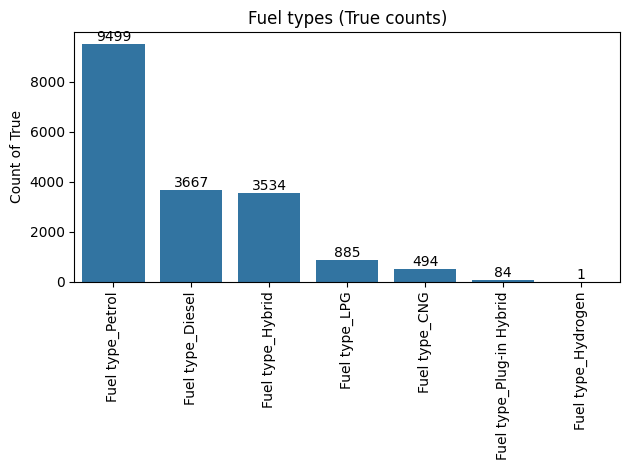

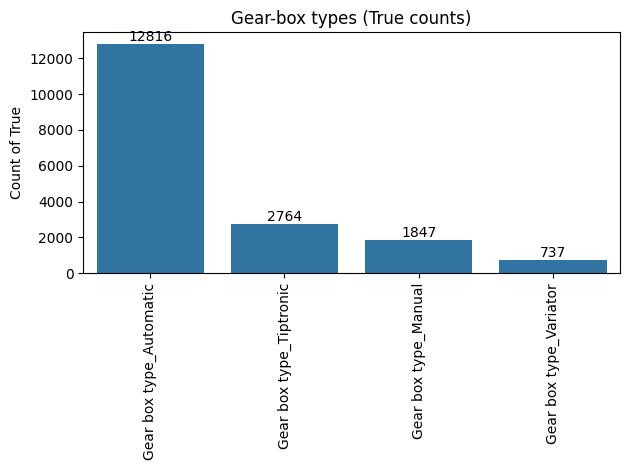

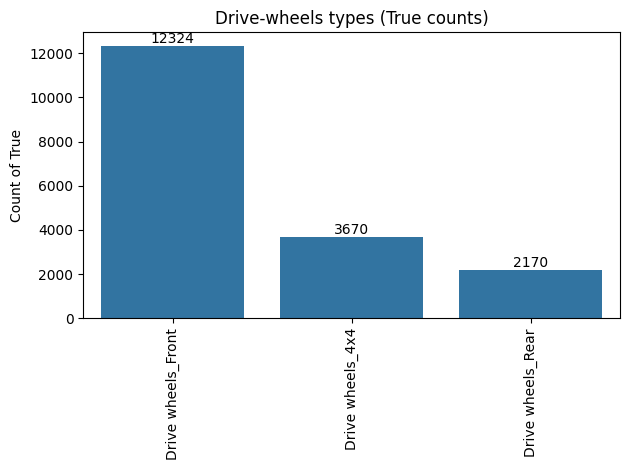

In [291]:
groups = {
    "Fuel types": fuel_cols,
    "Gear-box types": gear_box_cols,
    "Drive-wheels types": drive_wheels_cols,
}

for title, cols in groups.items():
    true_counts = temp_df[cols].sum().sort_values(ascending=False)

    ax = sns.barplot(x=true_counts.index, y=true_counts.values)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_xlabel("")
    ax.set_ylabel("Count of True")
    ax.set_title(f"{title} (True counts)")

    for idx, val in enumerate(true_counts.values):
        ax.text(idx, val, int(val), ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

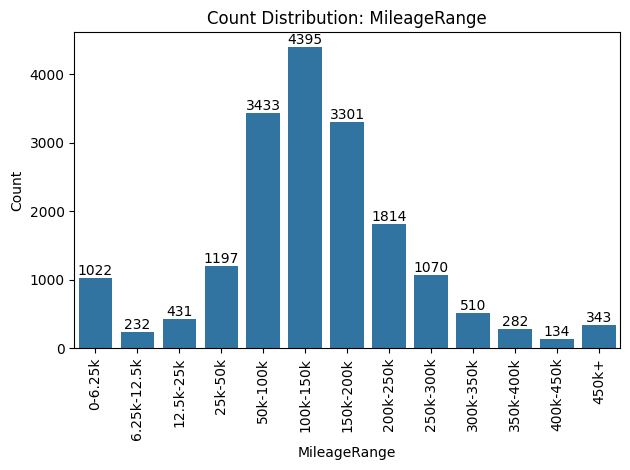

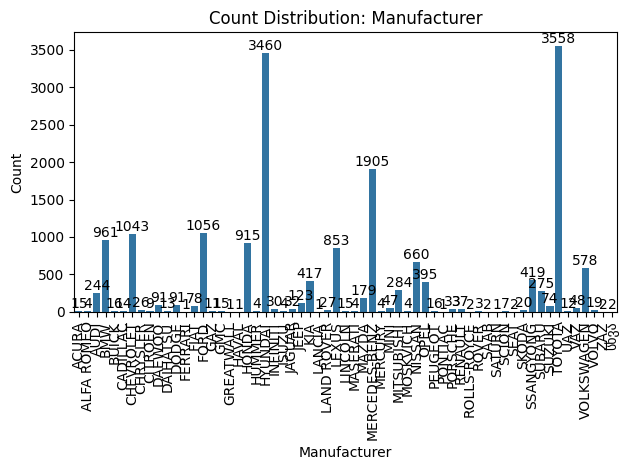

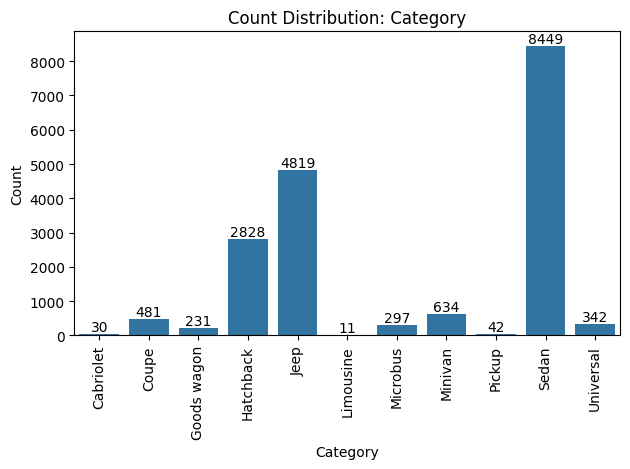

In [292]:
for col in other_cols:
    counts = temp_df[col].value_counts().sort_index()

    ax = sns.barplot(x=counts.index, y=counts.values)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.set_title(f'Count Distribution: {col}')

    for idx, val in enumerate(counts.values):
        ax.text(idx, val, int(val), ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

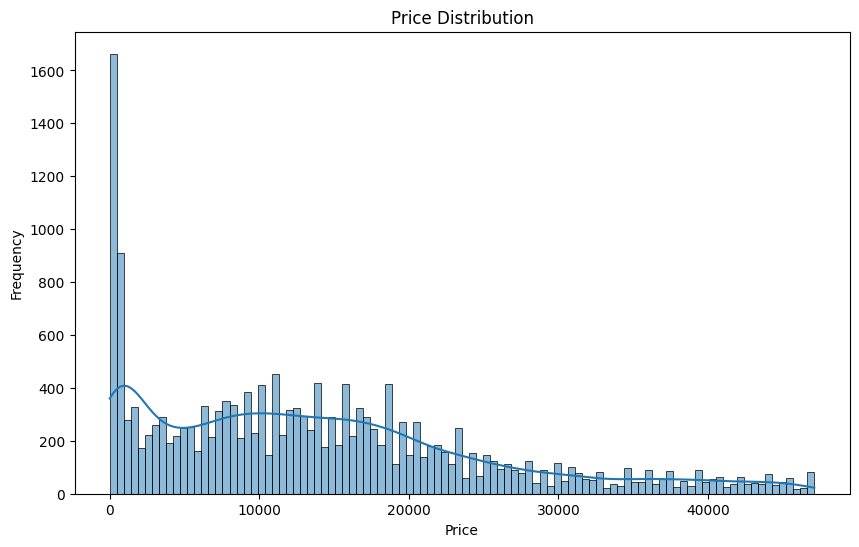

In [293]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], bins=100, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

__Explanation:__

We visualize the count distribution of key car attributes to understand which types dominate this dataset, to see whether it features mostly high-end luxury models or more common, budget-friendly vehicles.

From our analysis:
- **Category**: `Sedan` (7.999), `Jeep` (4.932), and `Hatchback` (2.531) are the most frequent body styles.
- **Manufacturer**: `Hyundai` leads with 3.629 listings, followed by `Toyota` (3.195) and `Mercedes-Benz` (1.814).
- **Fuel Type**: `Petrol` (9.318), `Diesel` (3.847), and `Hybrid` (2.959) are the top fuel options.
- **Gearbox Type**: Most cars are `Automatic` (11.991), then `Tiptronic` (3.032), `Manual` (1.836), and `Variator` (712).
- **Drive Wheels**: `Front`-wheel drive is most common (11.928), followed by `4×4` (3.507) and `Rear`-wheel drive (2.136).
- **Mileage Ranges**: Vehicles with 100.000–150.000 km (4.238) are most prevalent, then 50.000–100.000 km (3.581) and 150.000–200.000 km (3.125).

The price distribution is right-skewed, with the majority of listings priced below 200.000.

---

### 2.2 Scatter plot

In [294]:
def plot_multiple_scatters(df, x_cols, y_col='Price', cols_per_row=3):
    total_plots = len(x_cols)
    rows = (total_plots + cols_per_row - 1) // cols_per_row 

    plt.figure(figsize=(cols_per_row * 5, rows * 4))

    for i, col in enumerate(x_cols, 1):
        plt.subplot(rows, cols_per_row, i)
        sns.scatterplot(data=df, x=col, y=y_col)
        plt.title(f'{col} vs {y_col}')
        plt.xlabel(col)
        plt.ylabel(y_col)

    plt.tight_layout()
    plt.show()

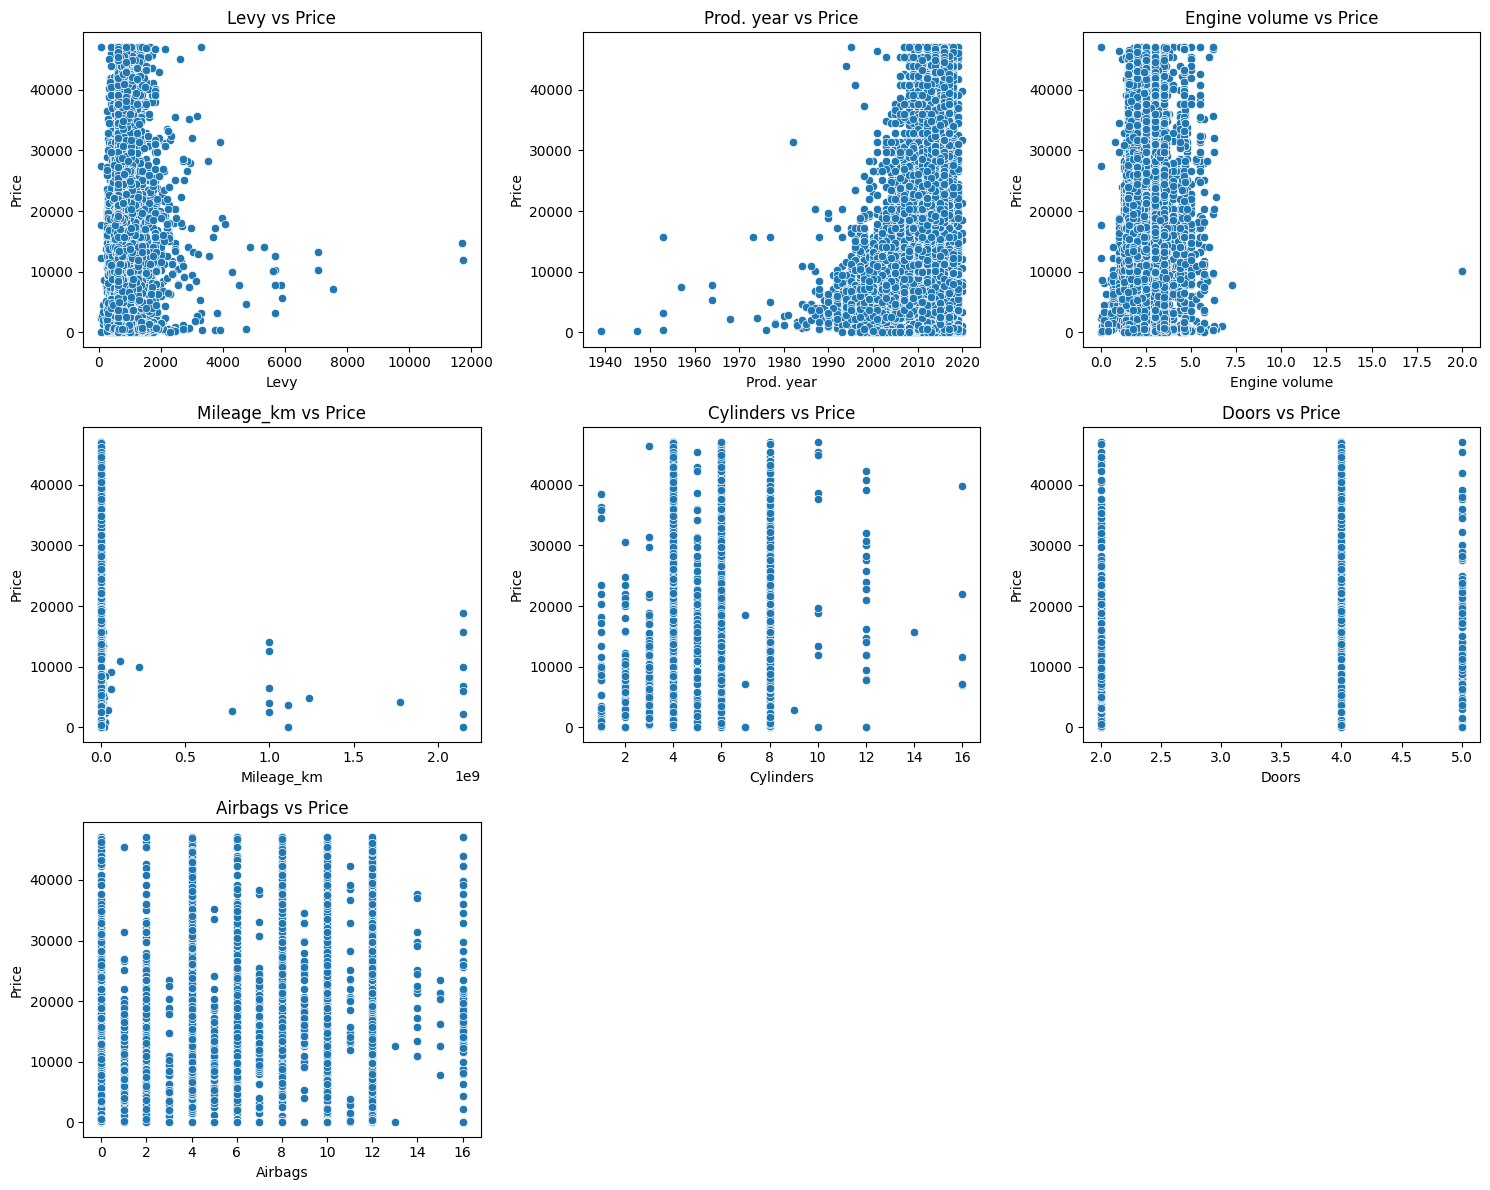

In [295]:
numeric_cols = ['Levy', 'Prod. year', 'Engine volume', 'Mileage_km', 'Cylinders', 'Doors', 'Airbags']

plot_multiple_scatters(df, numeric_cols)

__Explanation:__

We create scatter plots of `Price` versus several numerical features (`Levy`, `Prod. Year`, `Engine Volume`, `Mileage_km`, `Cylinders`, `Doors`, and `Airbags`) to assess any direct relationships with price.

From these plots, we observe **no strong linear trends** between individual features and price. This aligns with expectations: discrete features like `Cylinders`, `Doors`, and `Airbags` vary within limited ranges, and their impact on price depends heavily on **context** (e.g., luxury models may include more airbags without directly driving up price).

Overall, these findings indicate that **used car prices result from the interplay of multiple features** rather than any single predictor. This complexity explains why flexible models such as Random Forest and Gradient Boosting often outperform simple linear regressions in this domain.

---

#### 2.3 Correlation matrix

In [296]:
labes_to_encode = ['Manufacturer', 'Model', 'Category', 'Wheel', 'Color']

for label in labes_to_encode:
    le = LabelEncoder()
    df[label] = le.fit_transform(df[label])

df.iloc[0]

Price                        13328
Levy                          1399
Manufacturer                    29
Model                         1176
Prod. year                    2010
Category                         4
Leather interior                 1
Engine volume                 3.50
Mileage_km                  186005
Cylinders                     6.00
Doors                            4
Wheel                            0
Color                           12
Airbags                         12
turbo                            0
Fuel type_CNG                False
Fuel type_Diesel             False
Fuel type_Hybrid              True
Fuel type_Hydrogen           False
Fuel type_LPG                False
Fuel type_Petrol             False
Fuel type_Plug-in Hybrid     False
Drive wheels_4x4              True
Drive wheels_Front           False
Drive wheels_Rear            False
Gear box type_Automatic       True
Gear box type_Manual         False
Gear box type_Tiptronic      False
Gear box type_Variat

<Axes: >

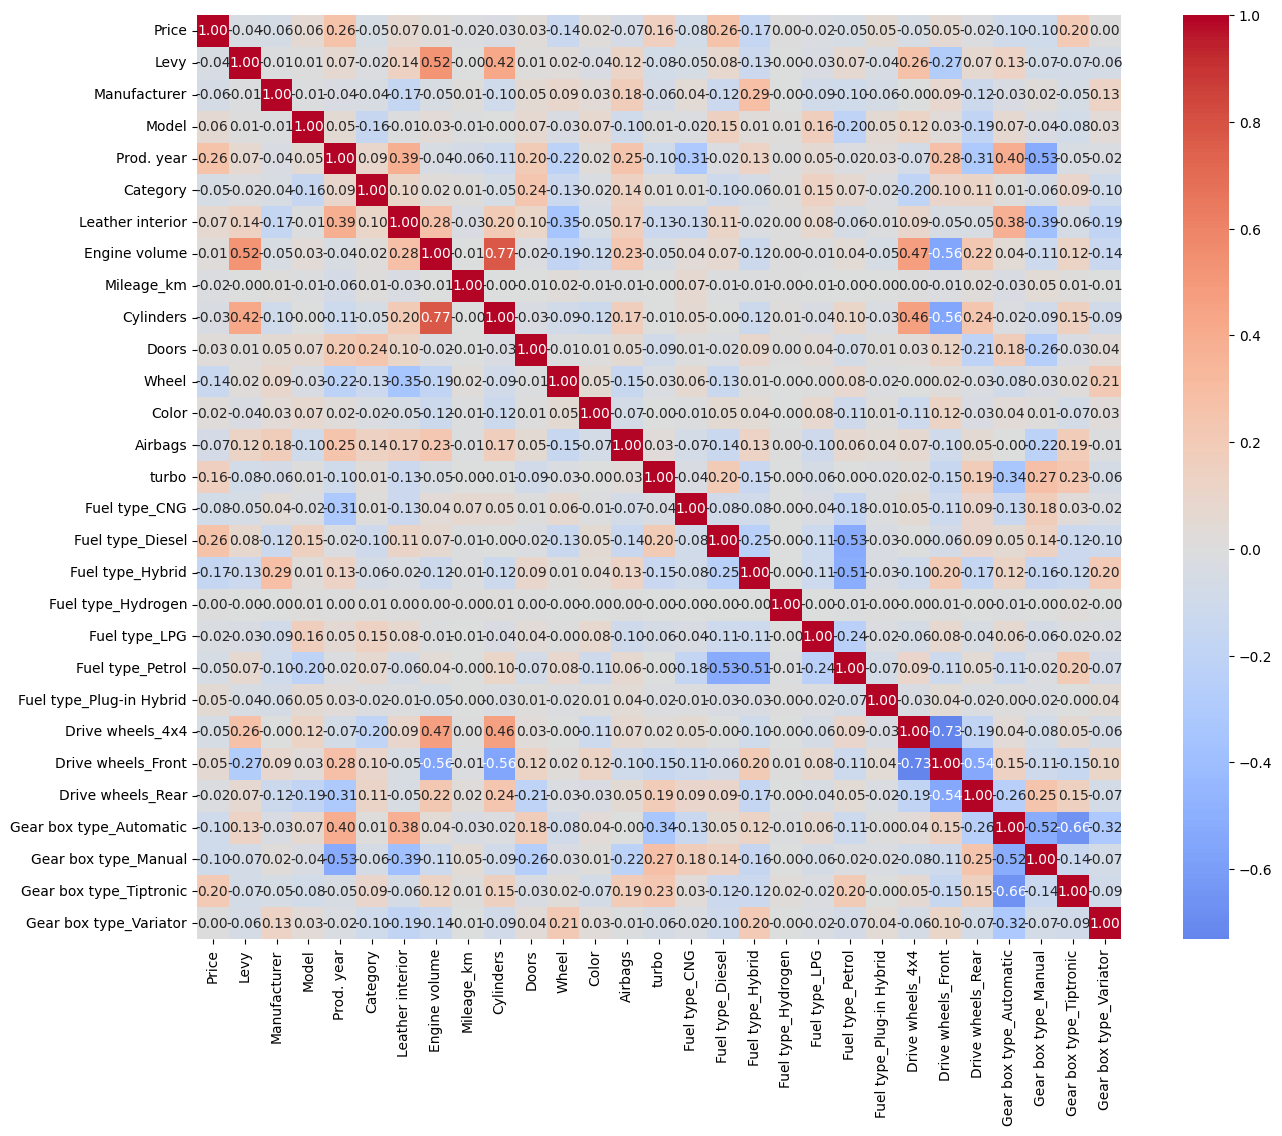

In [297]:
plt.figure(figsize=(16, 12))

sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0, square=True)

__Explanation:__

We first encode the categorical columns (`Manufacturer`, `Model`, `Category`, `Wheel`, and `Color`) using `LabelEncoder` to convert them into numeric labels. This allows us to compute correlations across all features and prepares the data for machine learning models.

To verify the encoding, we inspect a single row with `df.iloc[0]` and confirm each column's numeric value.

Next, we build a correlation matrix and visualize it with a heatmap. We set the figure size with Matplotlib, then use Seaborn's `heatmap()` with these parameters:
- `df.corr()`: correlation matrix of the DataFrame
- `annot=True`: show values in each cell
- `fmt=".2f"`: two-decimal format
- `cmap="coolwarm"`: diverging color map centered at zero
- `center=0`: center the color scale
- `square=True`: enforce square cells

The heatmap reveals mostly weak correlations, with many values hover near zero. Notably:
- `Levy` vs. `Price` correlation is **0.08**, almost negligible.
- `Mileage_km` vs. `Price` sits at **−0.02**, surprisingly close to zero.
- `Prod. Year` vs. `Price` shows a modest **0.30** correlation, indicating newer cars tend to cost more.

These results suggest that no single feature strongly predicts price on its own, reinforcing the need for models that capture feature interactions (e.g., Random Forest, Gradient Boosting).

---

## 3. Model Selection and training:

This section will include:
- Model selection
- Data splitting
- Model training & Validation
- Model evaluation

### 3.1 The Selected Models

__We have selected the following models for this project__:
- Multiple Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor (XGBoost)

__Reasons for model choice__:
- **Multiple Linear Regression (MLR)**

  Serves as a simple, interpretable baseline. Although relationships between features and price are not strictly linear, MLR helps quantify feature effects and offers computational efficiency.

- **Random Forest Regressor (RFR)**

  An ensemble of decision trees that captures nonlinear patterns, handles mixed data types, is robust to outliers and multicollinearity, and provides feature importance scores.

- **Gradient Boosting Regressor (XGBoost)**

  Builds trees sequentially to correct errors from prior models, achieving high accuracy on structured data. XGBoost's regularization and fine-grained parameter controls make it ideal for maximizing performance.

__Evaluation Metrics__:
- **R²**

  Proportion of variance in price explained by the model; higher is better.

- **Mean Absolute Error (MAE)**

  Average absolute difference between predicted and actual prices; intuitive and less sensitive to outliers.

- **Mean Squared Error (MSE)**

  Squares errors to penalize larger mistakes more heavily.

- **Root Mean Squared Error (RMSE)**

  Square root of MSE, returning errors to price units for interpretability.

> *Note:* Classification metrics (accuracy, precision, recall, F1) apply only if predicting categorical outcomes, not continuous prices.

__Hyperparameter Tuning__:

We will use `GridSearchCV` from scikit-learn to automate hyperparameter selection with cross-validation, ensuring we find robust settings for each model.

---

### 3.2 Data splitting into sets

In [298]:
df.columns

Index(['Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year', 'Category',
       'Leather interior', 'Engine volume', 'Mileage_km', 'Cylinders', 'Doors',
       'Wheel', 'Color', 'Airbags', 'turbo', 'Fuel type_CNG',
       'Fuel type_Diesel', 'Fuel type_Hybrid', 'Fuel type_Hydrogen',
       'Fuel type_LPG', 'Fuel type_Petrol', 'Fuel type_Plug-in Hybrid',
       'Drive wheels_4x4', 'Drive wheels_Front', 'Drive wheels_Rear',
       'Gear box type_Automatic', 'Gear box type_Manual',
       'Gear box type_Tiptronic', 'Gear box type_Variator'],
      dtype='object')

In [299]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['Price']), df['Price'], test_size=0.4, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

In [300]:
print(f"Train set shape: {X_train.shape[0]}, percentage: {X_train.shape[0] / df.shape[0] * 100:.2f}%")
print(f"Validation set shape: {X_val.shape[0]}, percentage: {X_val.shape[0] / df.shape[0] * 100:.2f}%")
print(f"Test set shape: {X_test.shape[0]}, percentage: {X_test.shape[0] / df.shape[0] * 100:.2f}%")

Train set shape: 10898, percentage: 60.00%
Validation set shape: 3633, percentage: 20.00%
Test set shape: 3633, percentage: 20.00%


__Explanation:__

We split the dataset into training, validation, and test sets in two stages. First, we reserve 40% of the data by setting `test_size=0.4` in `train_test_split`, leaving 60% for training. Next, we split that 40% equally into validation and test sets by using `test_size=0.5` in a second `train_test_split`, resulting in 20% validation and 20% test data.

We set `random_state=42` to ensure reproducible splits each time the code runs.

---

### 3.3 Model training and validation

This section will include:

- Helper functions
- Training, validating and saving models

*Helper methods for training, validation and testing the models*:

In [301]:
def display_grid_search_results(grid):
    results = grid.cv_results_

    print("GridSearchCV validation results:")
    print("Best parameters:", grid.best_params_)
    print("")

    for metric in ['r2', 'neg_mae', 'neg_mse', 'neg_rmse']:
        mean_score = results[f'mean_test_{metric}']
        print(f"{metric}:", mean_score[grid.best_index_])

In [302]:
scoring = {
    'r2': 'r2',
    'neg_mae': 'neg_mean_absolute_error',
    'neg_mse': 'neg_mean_squared_error',
    'neg_rmse': 'neg_root_mean_squared_error',
}

In [303]:
def evaluate_model(model, X, y):
    y_pred = model.predict(X)

    r2 = r2_score(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    rmse = root_mean_squared_error(y, y_pred)

    return r2, mse, mae, rmse

---

#### 3.3.1 Model 1: Multiple Linear Regression

In [304]:
mlr_param_grid = {}

mlr_grid = GridSearchCV(
    estimator=LinearRegression(),
    param_grid=mlr_param_grid,
    scoring=scoring,
    cv=5,
    refit='neg_rmse',
    n_jobs=-1,
)

mlr_grid.fit(X_train, y_train)

display_grid_search_results(mlr_grid)

mlr_best_model = mlr_grid.best_estimator_

GridSearchCV validation results:
Best parameters: {}

r2: 0.27494935496345924
neg_mae: -7553.517947510438
neg_mse: -93822608.04434676
neg_rmse: -9685.333731806539


In [305]:
val_r2, val_mse, val_mae, val_rmse = evaluate_model(mlr_best_model, X_val, y_val)

print(f"Validation R2: {val_r2:.4f}")
print(f"Validation MSE: {val_mse:.4f}")
print(f"Validation MAE: {val_mae:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")

Validation R2: 0.2543
Validation MSE: 97073957.2646
Validation MAE: 7628.9684
Validation RMSE: 9852.6117


In [306]:
with open(f'{base_path_models}mlr_best_model.pkl', 'wb') as f:
    pickle.dump(mlr_best_model, f)

---

#### 3.3.2 Model 2: Random Forest Regressor

In [307]:
rfr_param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

rfr_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rfr_param_grid,
    scoring=scoring,
    cv=5,
    refit='neg_rmse',
    n_jobs=-1,
)

rfr_grid.fit(X_train, y_train)

display_grid_search_results(rfr_grid)

rfr_best_model = rfr_grid.best_estimator_

GridSearchCV validation results:
Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

r2: 0.734750841664796
neg_mae: -3572.464623296557
neg_mse: -34338011.298438944
neg_rmse: -5857.960755394946


In [308]:
val_r2, val_mse, val_mae, val_rmse = evaluate_model(rfr_best_model, X_val, y_val)

print(f"Validation R2: {val_r2:.4f}")
print(f"Validation MSE: {val_mse:.4f}")
print(f"Validation MAE: {val_mae:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")

Validation R2: 0.7413
Validation MSE: 33677958.2941
Validation MAE: 3467.1347
Validation RMSE: 5803.2713


In [309]:
with open(f'{base_path_models}rfr_best_model.pkl', 'wb') as f:
    pickle.dump(rfr_best_model, f)

---

#### 3.3.3 Model 3: Gradient Boosting Regressors

In [310]:
gbr_param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 5, 10, 20, 30],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1],
}

gbr_grid = GridSearchCV(
    estimator=XGBRegressor(),
    param_grid=gbr_param_grid,
    scoring=scoring,
    cv=5,
    refit='neg_rmse',
    n_jobs=-1,
)

gbr_grid.fit(X_train, y_train)

display_grid_search_results(gbr_grid)

gbr_best_model = gbr_grid.best_estimator_

GridSearchCV validation results:
Best parameters: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 100, 'subsample': 0.8}

r2: 0.7425822734832763
neg_mae: -3524.348291015625
neg_mse: -33322406.0
neg_rmse: -5769.2376953125


In [311]:
val_r2, val_mse, val_mae, val_rmse = evaluate_model(gbr_best_model, X_val, y_val)

print(f"Validation R2: {val_r2:.4f}")
print(f"Validation MSE: {val_mse:.4f}")
print(f"Validation MAE: {val_mae:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")

Validation R2: 0.7483
Validation MSE: 32771198.0000
Validation MAE: 3461.3206
Validation RMSE: 5724.6133


In [312]:
with open(f'{base_path_models}gbr_best_model.pkl', 'wb') as f:
    pickle.dump(gbr_best_model, f)

---

__Explanation:__

**Hyperparameters for Grid Search:**

We use `GridSearchCV` from scikit-learn to find the optimal hyperparameters for each model by specifying:

1. **Estimator**: One of `LinearRegression`, `RandomForestRegressor`, or `GradientBoostingRegressor`.
2. **param_grid**: A dictionary mapping hyperparameter names to lists of values to try.
3. **scoring**: Our metrics dictionary.
4. **cv**: Number of cross-validation folds (5), balancing reliable error estimates and computational cost.
5. **refit**: Metric used to select the best model; set to `'neg_rmse'` so that the model with the lowest RMSE is chosen. RMSE is negative because `GridSearchCV` maximizes the score, and we want to minimize RMSE.
6. **n_jobs**: Set to `-1` to use all available CPU cores for parallel processing.

**Model-Specific Hyperparameters:**

- **Multiple Linear Regression**
  - No major tuning parameters beyond `fit_intercept` and `positive`; We include `GridSearchCV` for consistent baseline evaluation.

- **Random Forest Regressor**
  - `random_state`: Ensures reproducible results.
  - `n_estimators`: Number of trees in the forest.
  - `max_depth`: Maximum depth of each tree to control complexity.
  - `min_samples_split`: Minimum samples required to split an internal node.
  - `min_samples_leaf`: Minimum samples required to be at a leaf node.

- **Gradient Boosting Regressor (XGBoost)**
  - `n_estimators`: Number of boosting iterations.
  - `max_depth`: Maximum tree depth for each boosting round.
  - `learning_rate`: Shrinks the contribution of each tree.
  - `subsample`: Fraction of samples used per tree to introduce randomness and reduce overfitting.

**Tackling Overfitting:**

- **Cross-Validation**: 5-fold CV in `GridSearchCV` ensures models are assessed on multiple data splits.
- **Hyperparameter Control**: Parameters like `max_depth`, `min_samples_split`, and `n_estimators` regulate model complexity.
- **Subsampling**: Using `subsample < 1` in XGBoost adds randomness to reduce overfitting.
- **Evaluation & Validation Metrics**: Training and validation RMSE, MAE, and R² are compared (using a separate validation set after tuning) to spot overfitting (high training, low validation performance) or underfitting (poor performance on both).
- **Model Diversity**: Contrasting linear and tree-based methods helps identify which generalizes best.

---

### 3.4 Model evaluation

This section will include:

- Model evaluation
- Model comparison

#### 3.4.1 Model 1: Multiple Linear Regression

In [313]:
r2, mse, mae, rmse = evaluate_model(mlr_best_model, X_test, y_test)

print("MLR Evaluation on Test Set:")
print(f"R2: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MLR Evaluation on Test Set:
R2: 0.2672
MSE: 94055887.4856
MAE: 7602.2679
RMSE: 9698.2415


---

#### 3.4.2 Model 2: Random Forest Regressor

In [314]:
r2, mse, mae, rmse = evaluate_model(rfr_best_model, X_test, y_test)

print("RFR Evaluation on Test Set:")
print(f"R2: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

RFR Evaluation on Test Set:
R2: 0.7623
MSE: 30504279.4114
MAE: 3390.9978
RMSE: 5523.0679


---

#### 3.4.3 Model 3: Gradient Boosting Regressors

In [315]:
r2, mse, mae, rmse = evaluate_model(gbr_best_model, X_test, y_test)

print("GBR Evaluation on Test Set:")
print(f"R2: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

GBR Evaluation on Test Set:
R2: 0.7688
MSE: 29671826.0000
MAE: 3376.4031
RMSE: 5447.1851


---

#### 3.4.4 Comparison of Models

To compare the performance of the three regression models - Multiple Linear Regression (MLR), Random Forest Regressor (RFR) and Gradient Boosting Regressor (GBR) - we evaluated them on a held-out test set using four standard regression metrics:

| Model | R² (↑) | MAE (↓) | MSE (↓) | RMSE (↓) |
|-------|--------|----------|-------------|-------------|
| MLR   | 0,2672 | 7.602,27 | 94.055.887,49 | 9.698,24 |
| RFR   | 0,7623 | 3.391,00 | 30.504.279,41 | 5.523,07 |
| GBR   | **0,7688** | **3.376.40** | **29.671.826,00** | **5.447,19** |

- **R² Score**: Both RFR and GBR achieved significantly higher R² values (~0.76) compared to MLR (~0.26), indicating that tree-based models explained a much larger portion of the variance in car prices.

- **Other Evaluation Metrics**: MLR had the highest errors, with an average deviation of over 7.500. Both RFR and GBR cut the error by more than 50%, with GBR performing *slightly* better in all evaluation metrics.

- **Model Preference**: Both Random Forest and Gradient Boosting performed exceptionally well, but **GBR achieved the best values across all evaluation metrics**, making it the top choice on this dataset by a clear margin.

In contrast, **Multiple Linear Regression underperformed**, likely due to its inability to capture complex non-linear interactions present in the data.

---

**Conclusion**: Tree-based ensemble models, particularly Gradient Boosting Regressor, are better suited for used car price prediction tasks, as they handle non-linear relationships and mixed feature types more effectively than linear models.

#### 3.4.4 Comparison of Models

To compare the performance of the three regression models (Multiple Linear Regression (MLR), Random Forest Regressor (RFR), and Gradient Boosting Regressor (GBR)), we evaluated them on a held-out test set using four standard regression metrics:

| Model | R² (↑) | MAE (↓)      | MSE (↓)           | RMSE (↓)     |
|-------|--------|--------------|-------------------|--------------|
| MLR   | 0.2522 | 10,590.55    | 354,987,625.33    | 18,841.12    |
| RFR   | 0.7418 | **4,551.70** | 122,587,767.97    | 11,071.94    |
| GBR   | **0.7419** | 4,826.43     | **122,508,992.00** | **11,068.38** |

- **R² Score**: Both RFR and GBR achieved substantially higher R² (~0,74) than MLR (0,25), indicating the tree-based models explain far more variance in car prices.  
- **MAE / RMSE**: MLR's errors are highest, with an average deviation exceeding 10,000. RFR and GBR both reduce error by over 50%; GBR edges out RFR on RMSE and MSE, while RFR posts the lowest MAE.  
- **Model Preference**: Although RFR and GBR perform similarly, **GBR attains the lowest RMSE and MSE**, making it the best overall model by a small margin. RFR’s slightly lower MAE suggests it may incur fewer large individual prediction errors.  

In contrast, **Multiple Linear Regression underperforms**, likely because it cannot capture the complex non-linear interactions present in the dataset.

---

**Conclusion**: Tree-based ensemble models, especially Gradient Boosting Regressor, are better suited for used car price prediction, as they effectively model non-linear relationships and handle mixed feature types compared to linear approaches.

---

### 3.5 Manual testing of the models

This section will include:
- x
- y
- z

In [316]:
def create_test_data(
    prod_year,
    mileage,
    levy,
    engine_volume,
    cylinders,
    doors,
    leather_interior,
    turbo,
    fuel_type,
    drive_wheels,
    gear_box_type,
    model
):
    feature_names = model.get_booster().feature_names

    base = {
        'Prod. year':           [prod_year],
        'Mileage_km':           [mileage],
        'Levy':                 [levy],
        'Engine volume':        [engine_volume],
        'Cylinders':            [cylinders],
        'Doors':                [doors],
        'Leather interior':     [leather_interior],
        'turbo':                [turbo],
        # fuel dummies
        'Fuel type_CNG':                [1 if fuel_type == 'CNG' else 0],
        'Fuel type_Diesel':             [1 if fuel_type == 'Diesel' else 0],
        'Fuel type_Hybrid':             [1 if fuel_type == 'Hybrid' else 0],
        'Fuel type_Hydrogen':           [1 if fuel_type == 'Hydrogen' else 0],
        'Fuel type_LPG':                [1 if fuel_type == 'LPG' else 0],
        'Fuel type_Petrol':             [1 if fuel_type == 'Petrol' else 0],
        'Fuel type_Plug-in Hybrid':     [1 if fuel_type == 'Plug-in Hybrid' else 0],
        # drive wheels
        'Drive wheels_4x4':     [1 if drive_wheels == '4x4' else 0],
        'Drive wheels_Front':   [1 if drive_wheels == 'Front' else 0],
        'Drive wheels_Rear':    [1 if drive_wheels == 'Rear' else 0],
        # gearboxes
        'Gear box type_Automatic':  [1 if gear_box_type == 'Automatic' else 0],
        'Gear box type_Manual':     [1 if gear_box_type == 'Manual' else 0],
        'Gear box type_Tiptronic':  [1 if gear_box_type == 'Tiptronic' else 0],
        'Gear box type_Variator':   [1 if gear_box_type == 'Variator' else 0],
    }

    df = pd.DataFrame(base)
    return df.reindex(columns=feature_names, fill_value=0)

In [317]:
#gbr_best_model = pickle.load(open(f'{base_path_models}gbr_best_model.pkl', 'rb'))
#mlr_best_model = pickle.load(open(f'{base_path_models}mlr_best_model.pkl', 'rb'))
#rfr_best_model = pickle.load(open(f'{base_path_models}rfr_best_model.pkl', 'rb'))

test_params = [
    dict(prod_year=2020, mileage=15000, levy=0, engine_volume=2.0, cylinders=4, doors=4, leather_interior=1, fuel_type='Petrol',   drive_wheels='Front', gear_box_type='Automatic'),
    dict(prod_year=2018, mileage=30000, levy=0, engine_volume=1.5, cylinders=4, doors=4, leather_interior=0, fuel_type='Diesel',   drive_wheels='Rear',  gear_box_type='Manual'),
    dict(prod_year=2015, mileage=50000, levy=0, engine_volume=2.5, cylinders=6, doors=4, leather_interior=1, fuel_type='LPG',      drive_wheels='4x4',   gear_box_type='Automatic'),
    dict(prod_year=2019, mileage=20000, levy=0, engine_volume=1.8, cylinders=4, doors=4, leather_interior=1, fuel_type='Petrol',   drive_wheels='Front', gear_box_type='Manual'),
    dict(prod_year=2021, mileage=10000, levy=0, engine_volume=2.0, cylinders=4, doors=4, leather_interior=1, fuel_type='Diesel',   drive_wheels='Rear',  gear_box_type='Automatic'),
    dict(prod_year=2017, mileage=40000, levy=0, engine_volume=2.2, cylinders=4, doors=4, leather_interior=1, fuel_type='LPG',      drive_wheels='4x4',   gear_box_type='Manual'),
    dict(prod_year=2016, mileage=60000, levy=0, engine_volume=1.6, cylinders=4, doors=4, leather_interior=0, fuel_type='Petrol',   drive_wheels='Front', gear_box_type='Automatic'),
    dict(prod_year=2014, mileage=70000, levy=0, engine_volume=2.0, cylinders=4, doors=4, leather_interior=1, fuel_type='Diesel',   drive_wheels='Rear',  gear_box_type='Manual'),
    dict(prod_year=2013, mileage=80000, levy=0, engine_volume=2.5, cylinders=6, doors=4, leather_interior=1, fuel_type='LPG',      drive_wheels='4x4',   gear_box_type='Automatic'),
    dict(prod_year=2012, mileage=90000, levy=0, engine_volume=1.8, cylinders=4, doors=4, leather_interior=1, fuel_type='Petrol',   drive_wheels='Front', gear_box_type='Manual'),
]

for i, params in enumerate(test_params, start=1):
    test_df = create_test_data(prod_year=params['prod_year'],
                               mileage=params['mileage'],
                               levy=params['levy'],
                               engine_volume=params['engine_volume'],
                               cylinders=params['cylinders'],
                               doors=params['doors'],
                               leather_interior=params['leather_interior'],
                               turbo=0,
                               fuel_type=params['fuel_type'],
                               drive_wheels=params['drive_wheels'],
                               gear_box_type=params['gear_box_type'],
                               model=gbr_best_model
                              )

    print(f"Test {i}:\n", test_df, "\n")
    print(f"GBR Prediction: {gbr_best_model.predict(test_df)[0]:.2f}")
    print(f"MLR Prediction: {mlr_best_model.predict(test_df)[0]:.2f}")
    print(f"RFR Prediction: {rfr_best_model.predict(test_df)[0]:.2f}")
    print("-" * 40)

Test 1:
    Levy  Manufacturer  Model  Prod. year  Category  Leather interior  \
0     0             0      0        2020         0                 1   

   Engine volume  Mileage_km  Cylinders  Doors  ...  Fuel type_LPG  \
0           2.00       15000          4      4  ...              0   

   Fuel type_Petrol  Fuel type_Plug-in Hybrid  Drive wheels_4x4  \
0                 1                         0                 0   

   Drive wheels_Front  Drive wheels_Rear  Gear box type_Automatic  \
0                   1                  0                        1   

   Gear box type_Manual  Gear box type_Tiptronic  Gear box type_Variator  
0                     0                        0                       0  

[1 rows x 28 columns] 

GBR Prediction: 14599.73
MLR Prediction: 24896.68
RFR Prediction: 17925.38
----------------------------------------
Test 2:
    Levy  Manufacturer  Model  Prod. year  Category  Leather interior  \
0     0             0      0        2018         0         